# Cattle Breed Classification Using CNNs
### Comparative Analysis of a Custom CNN and Transfer Learning Models (MobileNetV2, ResNet50) with Explainable AI (Grad-CAM + SHAP)

This notebook designs, trains, evaluates and explains three deep-learning models that classify **cattle breeds** from images:

- a **Custom CNN** trained from scratch,
- **MobileNetV2** (ImageNet transfer learning), and
- **ResNet50** (ImageNet transfer learning).

The dataset is a standard **folder-per-breed** image dataset (each sub-folder is one breed). The notebook **auto-detects the breed folders and their names at runtime**, so it works with the recommended dataset or any cattle-breed image set laid out the same way.

It produces **every** output required by the class activity:
- Dataset description, model-architecture tables, evaluation metrics, confusion matrices, training curves
- Grad-CAM visualisations (correct + misclassified)
- SHAP visualisations
- A final comparison table

All **figures are shown inline and saved as PDF** (with PNG copies) and all **tables as CSV** into `/kaggle/working/outputs`, then the whole folder is **zipped for direct download**.

---
## Before you run (Kaggle settings)
1. **Add the dataset**: *Add Input* -> search "cattle breeds" and attach a folder-per-breed image dataset (recommended: `anandkumarsahu09/cattle-breeds-dataset`). The notebook auto-detects the folder that holds the breed sub-folders.
2. **Turn ON the GPU**: *Settings -> Accelerator -> GPU*.
3. **Turn ON Internet**: *Settings -> Internet -> On* (required to download the ImageNet weights for MobileNetV2 and ResNet50). If Internet is off, the notebook still runs but those two models start from random weights and become fully trainable.
4. **Run All**.
5. When finished, download the zip from the **Output** tab: `cattle_breed_outputs.zip`.


## 1. Imports, configuration and reproducibility

A single fixed seed (`42`) is used everywhere so the train/validation/test split and training are reproducible.

In [1]:
import os, random, glob, time, json, zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2, ResNet50

from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_recall_fscore_support)

# ---- Reproducibility ----
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Configuration ----
IMG_SIZE      = (224, 224)        # all models receive 224x224x3
BATCH_SIZE    = 16                 # small batch (dataset is modest in size)
EPOCHS        = 25                 # early stopping usually stops earlier
MIN_PER_CLASS = 5                  # ignore folders with fewer images than this
VAL_FRACTION  = 0.15
TEST_FRACTION = 0.15
# ImageNet weights are loaded automatically when Internet is ON; if it is OFF the
# transfer models fall back to random weights (see build_transfer). Turn Internet
# ON in Kaggle (Settings -> Internet) for far better results.

# ---- Output folders ----
OUT_DIR   = "/kaggle/working/outputs"
FIG_DIR   = os.path.join(OUT_DIR, "figures")
TAB_DIR   = os.path.join(OUT_DIR, "tables")
for d in (OUT_DIR, FIG_DIR, TAB_DIR):
    os.makedirs(d, exist_ok=True)

def save_fig(fig, name):
    # Save a matplotlib figure as both PDF and PNG, then show it inline.
    fig.savefig(os.path.join(FIG_DIR, name + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=130, bbox_inches="tight")
    plt.show()

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))


2026-06-26 12:58:06.346906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782478686.530602      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782478686.588572      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782478687.032587      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782478687.032630      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782478687.032633      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU available: True


## 2. Dataset auto-detection

This cell scans `/kaggle/input` (falling back to the working directory) and finds the directory that holds the **breed sub-folders**. It picks the folder with the most valid class sub-folders (each containing at least `MIN_PER_CLASS` images), so it is robust to datasets that wrap the breeds inside an extra parent folder.

In [2]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def count_images(folder):
    n = 0
    for f in os.listdir(folder):
        if f.lower().endswith(IMG_EXTS):
            n += 1
    return n

def find_image_root(search_roots=("/kaggle/input/datasets/anandkumarsahu09/cattle-breeds-dataset", ".")):
    # Return (root_dir, {class_name: count}) for the dir with the most valid class folders.
    best, best_classes = None, {}
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, dirs, _ in os.walk(root):
            classes = {}
            for d in dirs:
                sub = os.path.join(dirpath, d)
                c = count_images(sub)
                if c >= MIN_PER_CLASS:
                    classes[d] = c
            if len(classes) >= 2 and len(classes) > len(best_classes):
                best, best_classes = dirpath, classes
    return best, best_classes

DATA_DIR, class_counts = find_image_root()
assert DATA_DIR is not None, "No folder-per-class image dataset found under /kaggle/input."
CLASS_NAMES = sorted(class_counts.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("Dataset root :", DATA_DIR)
print("Breeds found :", NUM_CLASSES)
for c in CLASS_NAMES:
    print("  ", c.ljust(28), ":", class_counts[c], "images")
print("Total images :", sum(class_counts.values()))


Dataset root : /kaggle/input/datasets/anandkumarsahu09/cattle-breeds-dataset/Cattle Breeds
Breeds found : 5
   Ayrshire cattle              : 260 images
   Brown Swiss cattle           : 238 images
   Holstein Friesian cattle     : 254 images
   Jersey cattle                : 252 images
   Red Dane cattle              : 204 images
Total images : 1208


## 3. Dataset description

The breed names and per-breed image counts detected above, saved to CSV for the report.

In [3]:
desc = pd.DataFrame({"Breed": CLASS_NAMES,
                     "Num images": [class_counts[c] for c in CLASS_NAMES]})
desc.loc[len(desc)] = ["TOTAL", desc["Num images"].sum()]
desc["Image type"] = "RGB"
desc["Image size"] = str(IMG_SIZE[0]) + "x" + str(IMG_SIZE[1]) + " (resized)"
desc.to_csv(os.path.join(TAB_DIR, "dataset_description.csv"), index=False)
desc


,Breed,Num images,Image type,Image size
0,Ayrshire cattle,260,RGB,224x224 (resized)
1,Brown Swiss cattle,238,RGB,224x224 (resized)
2,Holstein Friesian cattle,254,RGB,224x224 (resized)
3,Jersey cattle,252,RGB,224x224 (resized)
4,Red Dane cattle,204,RGB,224x224 (resized)
5,TOTAL,1208,RGB,224x224 (resized)


## Figure 1 - Dataset samples

A grid of example images for each breed.

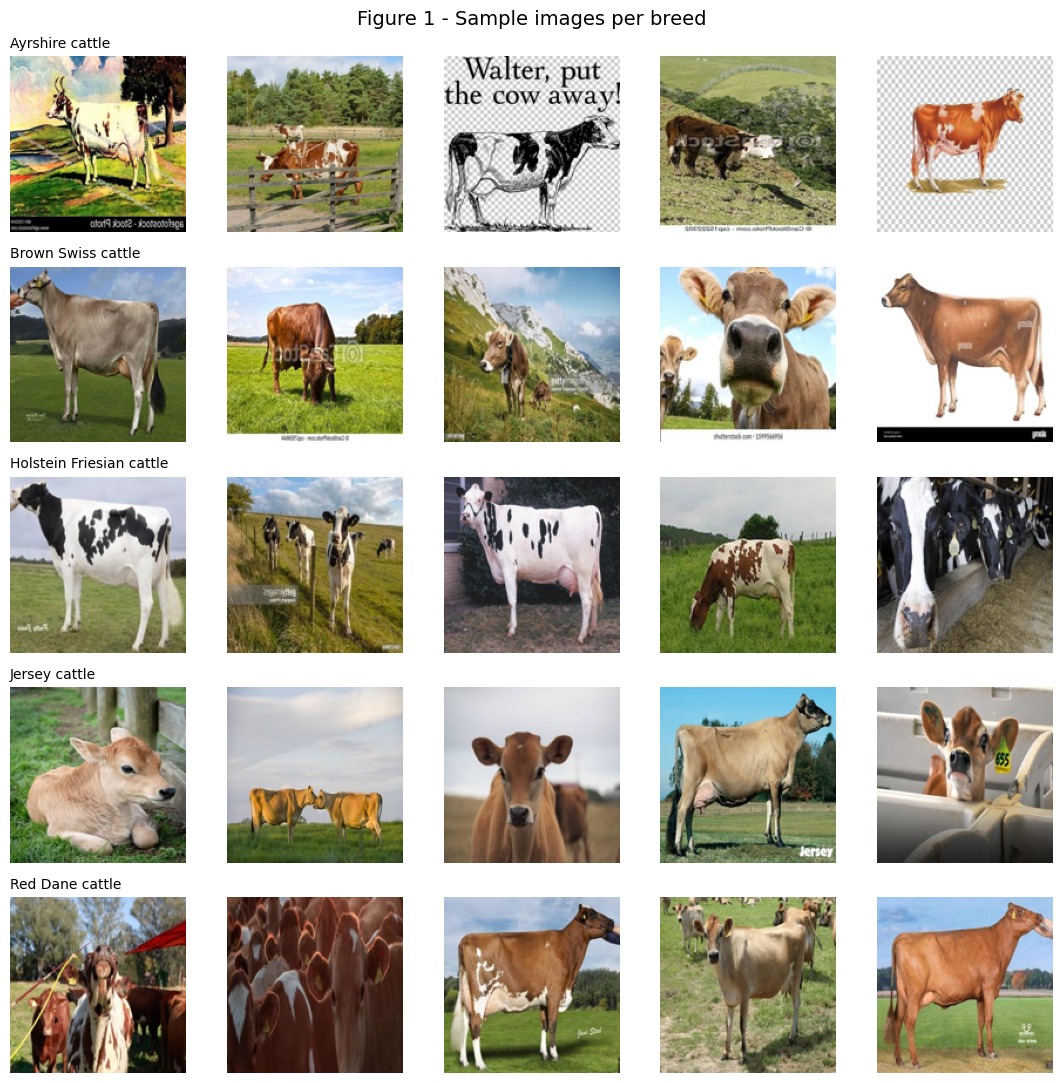

In [4]:
n_show = 5
fig, axes = plt.subplots(NUM_CLASSES, n_show, figsize=(n_show * 2.2, NUM_CLASSES * 2.2))
if NUM_CLASSES == 1:
    axes = np.expand_dims(axes, 0)
for r, c in enumerate(CLASS_NAMES):
    files = [f for f in glob.glob(os.path.join(DATA_DIR, c, "*")) if f.lower().endswith(IMG_EXTS)][:n_show]
    for k in range(n_show):
        ax = axes[r][k] if NUM_CLASSES > 1 else axes[k]
        ax.axis("off")
        if k < len(files):
            try:
                ax.imshow(Image.open(files[k]).convert("RGB").resize((150, 150)))
            except Exception:
                pass
        if k == 0:
            ax.set_title(c, fontsize=10, loc="left")
fig.suptitle("Figure 1 - Sample images per breed", fontsize=14)
fig.tight_layout()
save_fig(fig, "Figure1_dataset_samples")


## Figure 2 - Model design workflow

A simple block diagram of the pipeline, drawn with matplotlib so it is saved alongside the other figures.

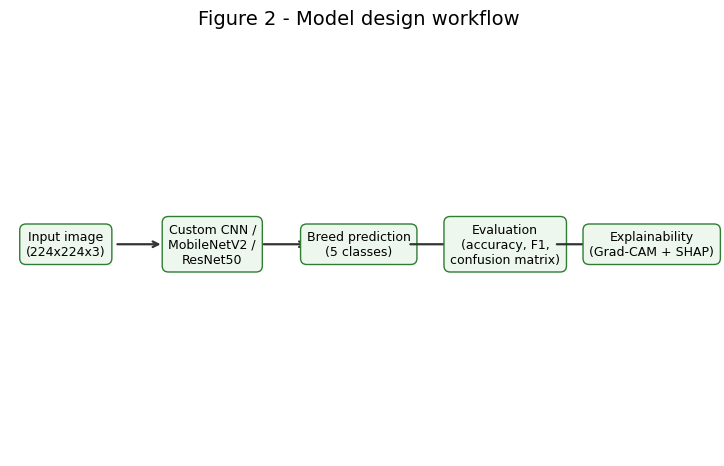

Saved workflow diagram.


In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axis("off")
steps = ["Input image\n(224x224x3)",
         "Custom CNN /\nMobileNetV2 /\nResNet50",
         "Breed prediction\n(" + str(NUM_CLASSES) + " classes)",
         "Evaluation\n(accuracy, F1,\nconfusion matrix)",
         "Explainability\n(Grad-CAM + SHAP)"]
y = 0.5
xs = np.linspace(0.08, 0.92, len(steps))
for i, (x, s) in enumerate(zip(xs, steps)):
    ax.text(x, y, s, ha="center", va="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.5", fc="#eef7ee", ec="#2e7d32"))
    if i < len(steps) - 1:
        ax.annotate("", xy=(xs[i + 1] - 0.07, y), xytext=(x + 0.07, y),
                    arrowprops=dict(arrowstyle="->", lw=1.6, color="#333"))
ax.set_title("Figure 2 - Model design workflow", fontsize=14)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
save_fig(fig, "Figure2_workflow")
print("Saved workflow diagram.")


## 4. Train / validation / test pipelines

Images are loaded with `image_dataset_from_directory` at **raw `[0,255]` scale** (normalisation is baked into each model later, so Grad-CAM and SHAP overlays stay interpretable on the original pixels). A held-out **test** split is carved out first, then the remainder is split into **train** and **validation**. Light augmentation (flip, small rotation/zoom/contrast) is applied to the training set only - useful here because cattle-breed datasets are usually modest in size.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, labels="inferred", label_mode="int",
    class_names=CLASS_NAMES, image_size=IMG_SIZE, batch_size=None,
    shuffle=True, seed=SEED)

n_total = full_ds.cardinality().numpy()
n_test  = max(1, int(n_total * TEST_FRACTION))
n_val   = max(1, int(n_total * VAL_FRACTION))
n_train = n_total - n_test - n_val
print("Total images:", n_total, " -> train", n_train, "| val", n_val, "| test", n_test)

full_ds = full_ds.shuffle(n_total, seed=SEED, reshuffle_each_iteration=False)
test_ds  = full_ds.take(n_test)
rest_ds  = full_ds.skip(n_test)
val_ds   = rest_ds.take(n_val)
train_ds = rest_ds.skip(n_val)

y_train = np.array([int(y.numpy()) for _, y in train_ds])
cls, cnt = np.unique(y_train, return_counts=True)
class_weight = {int(c): float(len(y_train) / (len(cls) * n)) for c, n in zip(cls, cnt)}
print("Class weights:", class_weight)

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.08, seed=SEED),
    layers.RandomZoom(0.12, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="augment")

def prep(ds, training=False):
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_pipe = prep(train_ds, training=True)
val_pipe   = prep(val_ds)
test_pipe  = prep(test_ds)


Found 1208 files belonging to 5 classes.


I0000 00:00:1782478750.617679      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Total images: 1208  -> train 846 | val 181 | test 181
Class weights: {0: 0.9452513966480447, 1: 1.0071428571428571, 2: 0.9245901639344263, 3: 0.9952941176470588, 4: 1.158904109589041}


## 5. Model definitions

Three architectures. Preprocessing is **built into each model** so all three share the same raw `[0,255]` input pipeline:

- **Custom CNN** - `Rescaling(1/255)` then 3 conv blocks -> GAP -> dropout -> dense.
- **MobileNetV2** - `Rescaling(1/127.5, offset=-1)` (maps to `[-1,1]`, the scale ImageNet MobileNetV2 expects) then the frozen ImageNet base + a lightweight head.
- **ResNet50** - `resnet50.preprocess_input` then the frozen ImageNet base + a lightweight head.

For each model we also keep a reference to the **last convolutional feature tensor** at build time and build a `grad_model` from it. Capturing the tensor during construction (rather than digging it out of a nested base afterwards) is what makes Grad-CAM work cleanly on the transfer-learning models without graph-disconnect errors.

In [10]:
def build_custom_cnn():
    inp = layers.Input(shape=IMG_SIZE + (3,))
    x = layers.Rescaling(1.0 / 255)(inp)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    feat = layers.Conv2D(128, 3, padding="same", activation="relu", name="last_conv")(x)
    x = layers.GlobalAveragePooling2D()(feat)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out, name="Custom_CNN")
    grad_model = models.Model(inp, [feat, out])
    return model, grad_model

def build_transfer(base_ctor, preprocess_layer, name):
    inp = layers.Input(shape=IMG_SIZE + (3,))
    x = preprocess_layer(inp)
    # Try to load ImageNet weights. If there is no Internet (weights cannot be
    # downloaded), fall back to random initialisation and make the base trainable
    # so the notebook still runs end to end instead of crashing.
    try:
        base = base_ctor(include_top=False, weights="imagenet",
                         input_shape=IMG_SIZE + (3,))
        pretrained = True
    except Exception as e:
        print("[", name, "] Could not download ImageNet weights -",
              "falling back to random init. Turn Kaggle Internet ON for far",
              "better results. Reason:", type(e).__name__)
        base = base_ctor(include_top=False, weights=None,
                         input_shape=IMG_SIZE + (3,))
        pretrained = False
    base.trainable = (not pretrained)       # freeze if pretrained, train if random
    feat = base(x)                          # last conv feature map - captured here
    x = layers.GlobalAveragePooling2D()(feat)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out, name=name)
    grad_model = models.Model(inp, [feat, out])
    return model, grad_model

def build_mobilenet():
    pp = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="mnv2_preprocess")
    return build_transfer(MobileNetV2, pp, "MobileNetV2")

def build_resnet():
    pp = layers.Lambda(tf.keras.applications.resnet50.preprocess_input,
                       name="resnet_preprocess")
    return build_transfer(ResNet50, pp, "ResNet50")

BUILDERS = {"Custom CNN": build_custom_cnn,
            "MobileNetV2": build_mobilenet,
            "ResNet50": build_resnet}

arch_rows = []
for nm, fn in BUILDERS.items():
    m, _ = fn()
    total = m.count_params()
    trainable = int(sum(np.prod(w.shape) for w in m.trainable_weights))
    arch_rows.append({"Model": nm, "Total params": total,
                      "Trainable params": trainable,
                      "Frozen params": total - trainable})
    del m
arch_df = pd.DataFrame(arch_rows)
arch_df.to_csv(os.path.join(TAB_DIR, "model_architecture.csv"), index=False)
arch_df


,Model,Total params,Trainable params,Frozen params
0,Custom CNN,93893,93893,0
1,MobileNetV2,2264389,6405,2257984
2,ResNet50,23597957,10245,23587712


## 6. Training

Each model is trained with Adam, sparse categorical cross-entropy, class weights, and **early stopping** on validation loss (`restore_best_weights=True`). We record the training history, wall-clock training time, and parameter count for each model.

In [11]:
histories, trained, grad_models, train_times = {}, {}, {}, {}

for nm, fn in BUILDERS.items():
    print("\n=== Training", nm, "===")
    tf.random.set_seed(SEED)
    model, grad_model = fn()
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    es = callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                 restore_best_weights=True)
    t0 = time.time()
    h = model.fit(train_pipe, validation_data=val_pipe, epochs=EPOCHS,
                  class_weight=class_weight, callbacks=[es], verbose=2)
    train_times[nm] = time.time() - t0
    histories[nm] = h.history
    trained[nm] = model
    grad_models[nm] = grad_model
    print(nm, "trained in", round(train_times[nm], 1), "s")



=== Training Custom CNN ===
Epoch 1/25


I0000 00:00:1782478804.911372     135 service.cc:152] XLA service 0x7f4d9808c450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782478804.911412     135 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782478805.531990     135 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782478808.757327     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


53/53 - 14s - 262ms/step - accuracy: 0.2258 - loss: 1.6064 - val_accuracy: 0.2762 - val_loss: 1.5618
Epoch 2/25
53/53 - 6s - 105ms/step - accuracy: 0.3085 - loss: 1.5435 - val_accuracy: 0.3702 - val_loss: 1.4176
Epoch 3/25
53/53 - 6s - 106ms/step - accuracy: 0.3511 - loss: 1.4598 - val_accuracy: 0.3591 - val_loss: 1.4761
Epoch 4/25
53/53 - 6s - 105ms/step - accuracy: 0.3889 - loss: 1.4268 - val_accuracy: 0.3702 - val_loss: 1.4287
Epoch 5/25
53/53 - 5s - 103ms/step - accuracy: 0.4090 - loss: 1.3855 - val_accuracy: 0.4365 - val_loss: 1.3539
Epoch 6/25
53/53 - 6s - 104ms/step - accuracy: 0.3995 - loss: 1.3977 - val_accuracy: 0.4199 - val_loss: 1.3361
Epoch 7/25
53/53 - 6s - 105ms/step - accuracy: 0.4704 - loss: 1.3741 - val_accuracy: 0.4696 - val_loss: 1.2814
Epoch 8/25
53/53 - 6s - 104ms/step - accuracy: 0.4539 - loss: 1.3364 - val_accuracy: 0.5580 - val_loss: 1.2161
Epoch 9/25
53/53 - 5s - 103ms/step - accuracy: 0.4728 - loss: 1.3320 - val_accuracy: 0.5635 - val_loss: 1.1853
Epoch 10/25

## 7. Evaluation

For each model we compute accuracy, weighted and macro precision/recall/F1 on the held-out test set, plus a full classification report saved to CSV.

In [12]:
X_test, y_test = [], []
for xb, yb in test_pipe:
    X_test.append(xb.numpy()); y_test.append(yb.numpy())
X_test = np.concatenate(X_test); y_test = np.concatenate(y_test)
print("Test tensor:", X_test.shape)

metric_rows, preds_store = [], {}
for nm, model in trained.items():
    probs = model.predict(X_test, verbose=0)
    yhat = probs.argmax(1)
    preds_store[nm] = yhat
    acc = accuracy_score(y_test, yhat)
    pw, rw, fw, _ = precision_recall_fscore_support(y_test, yhat, average="weighted", zero_division=0)
    pm, rm, fm, _ = precision_recall_fscore_support(y_test, yhat, average="macro", zero_division=0)
    metric_rows.append({"Model": nm, "Accuracy": round(acc, 4),
                        "Precision (w)": round(pw, 4), "Recall (w)": round(rw, 4),
                        "F1 (w)": round(fw, 4), "F1 (macro)": round(fm, 4),
                        "Train time (s)": round(train_times[nm], 1),
                        "Params": trained[nm].count_params()})
    rep = classification_report(y_test, yhat, target_names=CLASS_NAMES,
                                output_dict=True, zero_division=0)
    pd.DataFrame(rep).transpose().to_csv(
        os.path.join(TAB_DIR, "classification_report_" + nm.replace(" ", "_") + ".csv"))

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(os.path.join(TAB_DIR, "evaluation_metrics.csv"), index=False)
metrics_df


Test tensor: (181, 224, 224, 3)


,Model,Accuracy,Precision (w),Recall (w),F1 (w),F1 (macro),Train time (s),Params
0,Custom CNN,0.6409,0.6570,0.6409,0.6376,0.6346,146.8,93893
1,MobileNetV2,0.8564,0.8732,0.8564,0.8568,0.8519,118.4,2264389
2,ResNet50,0.9503,0.9525,0.9503,0.9502,0.9488,169.8,23597957


## Figure 3 - Accuracy and loss curves

Training vs validation accuracy and loss for all three models.

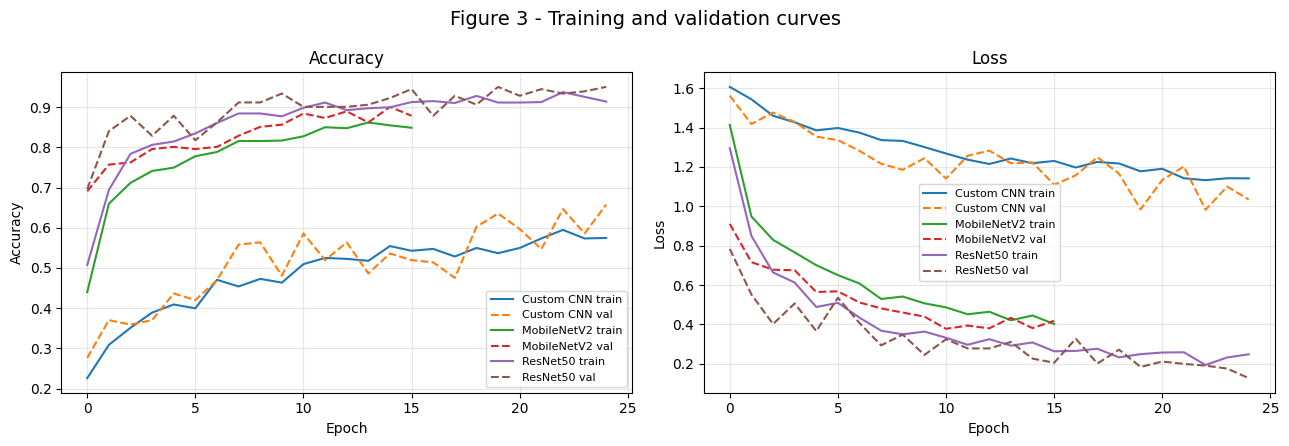

Saved training curves.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for nm, h in histories.items():
    axes[0].plot(h["accuracy"], label=nm + " train")
    axes[0].plot(h["val_accuracy"], "--", label=nm + " val")
    axes[1].plot(h["loss"], label=nm + " train")
    axes[1].plot(h["val_loss"], "--", label=nm + " val")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
for a in axes:
    a.legend(fontsize=8); a.grid(alpha=0.3)
fig.suptitle("Figure 3 - Training and validation curves", fontsize=14)
fig.tight_layout()
save_fig(fig, "Figure3_training_curves")
print("Saved training curves.")


## Figure 4 - Confusion matrix comparison

One confusion matrix per model on the test set.

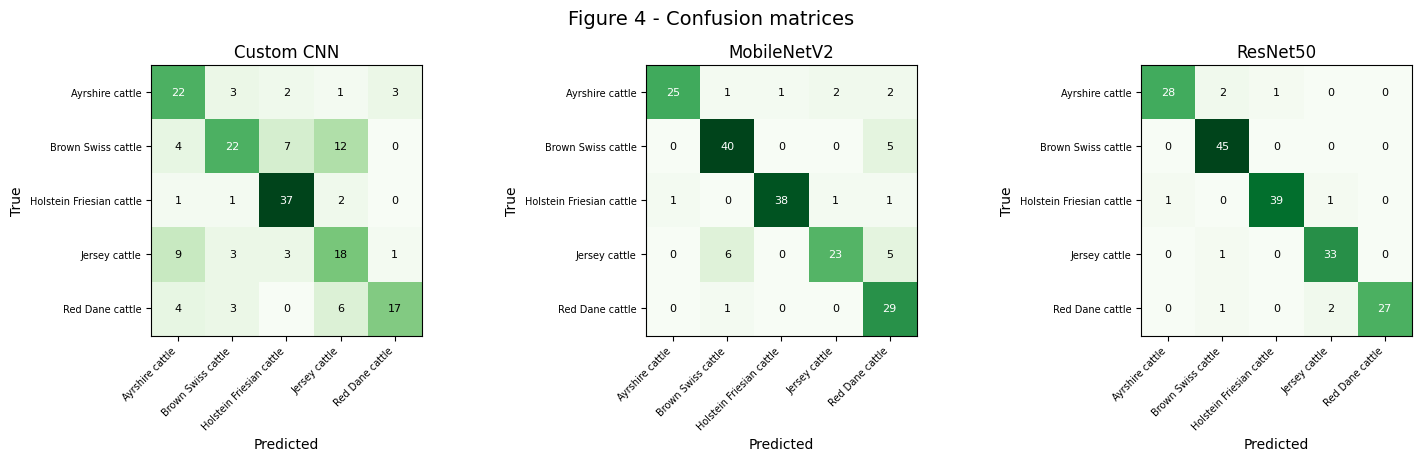

Saved confusion matrices.


In [14]:
fig, axes = plt.subplots(1, len(trained), figsize=(5 * len(trained), 4.6))
if len(trained) == 1:
    axes = [axes]
for ax, (nm, yhat) in zip(axes, preds_store.items()):
    cm = confusion_matrix(y_test, yhat, labels=range(NUM_CLASSES))
    ax.imshow(cm, cmap="Greens")
    ax.set_title(nm)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
        os.path.join(TAB_DIR, "confusion_matrix_" + nm.replace(" ", "_") + ".csv"))
fig.suptitle("Figure 4 - Confusion matrices", fontsize=14)
fig.tight_layout()
save_fig(fig, "Figure4_confusion_matrices")
print("Saved confusion matrices.")


## 8. Grad-CAM

Grad-CAM highlights the image regions most responsible for a prediction. We use the `grad_model` (built earlier) that returns the last convolutional feature map and the class probabilities. We show Grad-CAM for **correctly** classified images (Figure 5) and **misclassified** images (Figure 6), across all three models. Misclassifications are pooled across all models so Figure 6 is populated even if one model happens to be perfect on the test set.

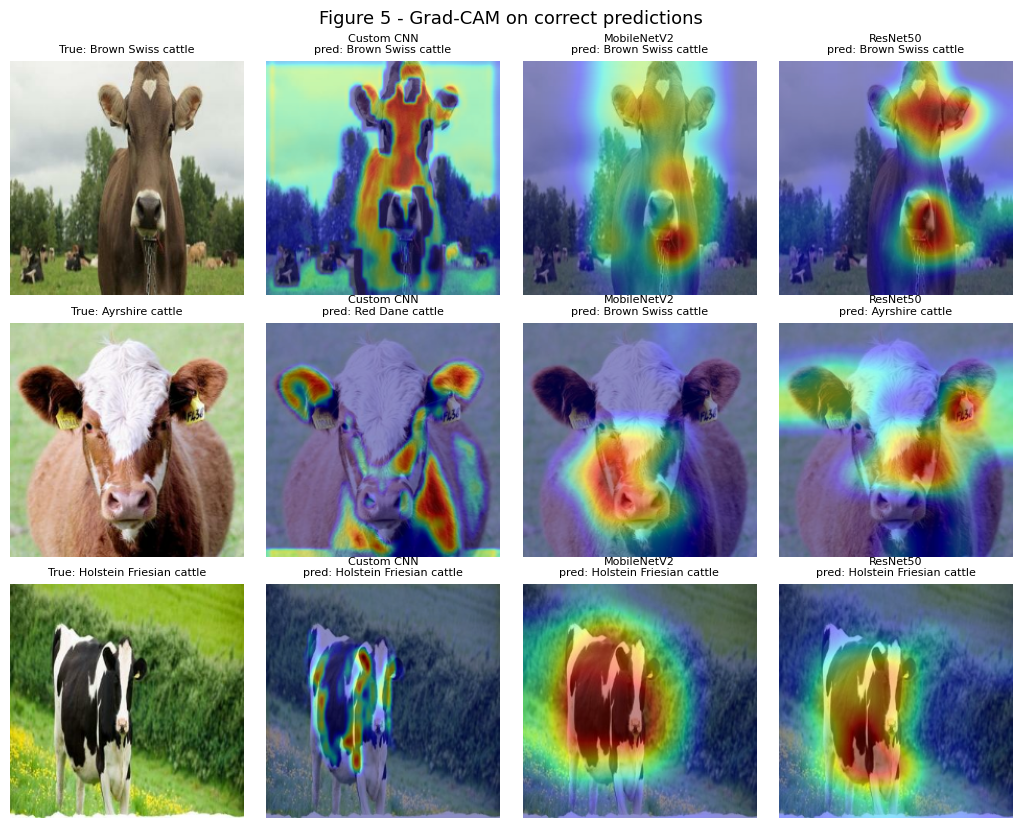

Saved Figure5_gradcam_correct


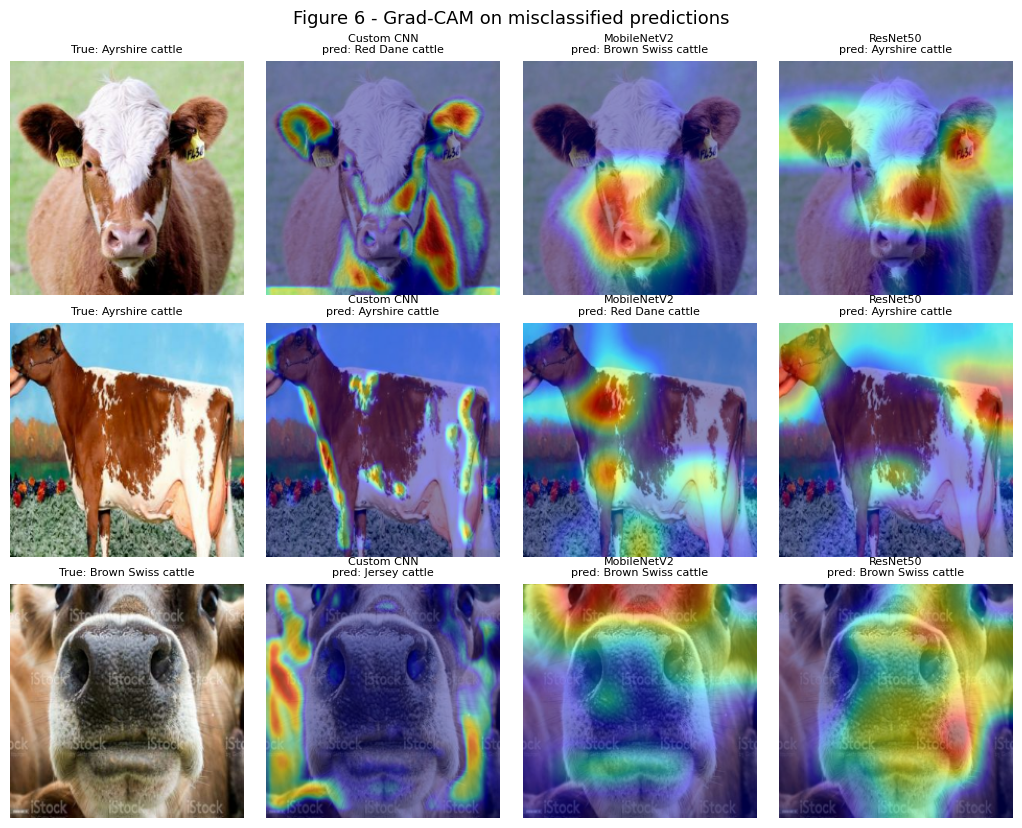

Saved Figure6_gradcam_misclassified


In [15]:
def gradcam_heatmap(grad_model, img, class_idx):
    # Compute a Grad-CAM heatmap for one image (HxWx3, [0,255] scale).
    arr = tf.convert_to_tensor(img[None].astype("float32"))
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(arr)
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam = tf.reduce_sum(conv_out[0] * weights, axis=-1).numpy()
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)
    cam = np.array(Image.fromarray((cam * 255).astype("uint8")).resize(IMG_SIZE))
    return cam / 255.0

def overlay(ax, img, cam, title):
    ax.imshow(img.astype("uint8"))
    ax.imshow(cam, cmap="jet", alpha=0.45)
    ax.set_title(title, fontsize=8); ax.axis("off")

ref_model = "ResNet50" if "ResNet50" in preds_store else list(preds_store)[0]
correct_idx = np.where(preds_store[ref_model] == y_test)[0]
# Pool misclassifications across ALL models so Figure 6 is populated even when
# the reference model classifies the test set perfectly.
any_wrong = np.zeros(len(y_test), dtype=bool)
for nm in preds_store:
    any_wrong |= (preds_store[nm] != y_test)
incorrect_idx = np.where(any_wrong)[0]
rng = np.random.default_rng(SEED)
sel_correct   = rng.choice(correct_idx, size=min(3, len(correct_idx)), replace=False) if len(correct_idx) else []
sel_incorrect = rng.choice(incorrect_idx, size=min(3, len(incorrect_idx)), replace=False) if len(incorrect_idx) else []

def gradcam_grid(indices, fname, title):
    if len(indices) == 0:
        print("No samples available for", title); return
    ncol = len(trained) + 1
    fig, axes = plt.subplots(len(indices), ncol, figsize=(2.6 * ncol, 2.8 * len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, 0)
    for r, idx in enumerate(indices):
        img = X_test[idx]
        axes[r][0].imshow(img.astype("uint8")); axes[r][0].axis("off")
        axes[r][0].set_title("True: " + CLASS_NAMES[y_test[idx]], fontsize=8)
        for k, nm in enumerate(trained):
            pred = preds_store[nm][idx]
            cam = gradcam_heatmap(grad_models[nm], img, pred)
            overlay(axes[r][k + 1], img, cam, nm + "\npred: " + CLASS_NAMES[pred])
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    save_fig(fig, fname)
    print("Saved", fname)

gradcam_grid(sel_correct,   "Figure5_gradcam_correct",       "Figure 5 - Grad-CAM on correct predictions")
gradcam_grid(sel_incorrect, "Figure6_gradcam_misclassified", "Figure 6 - Grad-CAM on misclassified predictions")


## 9. SHAP

SHAP estimates how each region pushes the prediction toward (red) or away from (blue) the predicted class. SHAP can be sensitive to library versions, so this cell is defensive: it tries `GradientExplainer` on a small set of test images and, if anything fails, saves a clearly labelled placeholder figure instead of stopping the notebook. The prediction function passed to SHAP works on `[0,1]` images and rescales to `[0,255]` internally, matching the models' raw-pixel input.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1587
Received: inputs=['Tensor(shape=(3, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1587
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2293639883864671e-08..1.3541239241021685e-08].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow wi

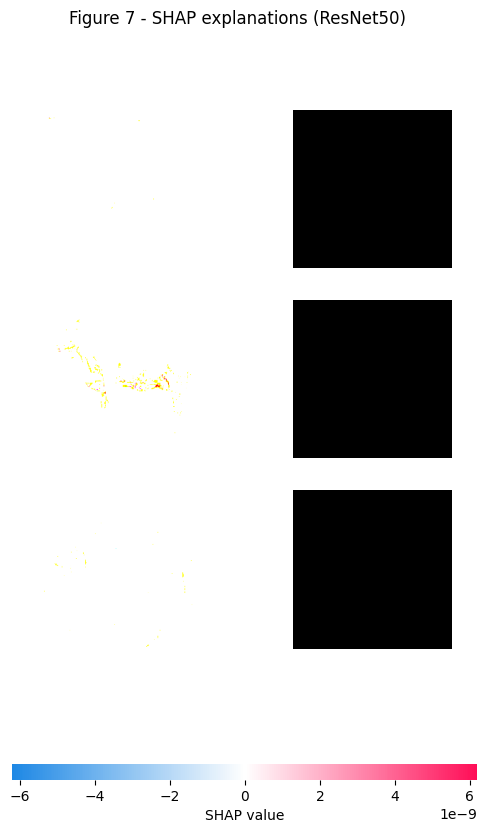

Saved SHAP figure for ResNet50


In [16]:
try:
    import shap
    bg_n, ex_n = 25, 3
    rng2 = np.random.default_rng(SEED)
    bg_idx = rng2.choice(len(X_test), size=min(bg_n, len(X_test)), replace=False)
    ex_idx = rng2.choice(len(X_test), size=min(ex_n, len(X_test)), replace=False)

    # SHAP works in [0,1]; predict_fn rescales back to [0,255] for the models.
    background01 = (X_test[bg_idx] / 255.0).astype("float32")
    examples01   = (X_test[ex_idx] / 255.0).astype("float32")

    shap_model = trained[ref_model]
    def predict_fn(x01):
        return shap_model.predict((x01 * 255.0).astype("float32"), verbose=0)

    explainer = shap.GradientExplainer(shap_model, (background01 * 255.0).astype("float32"))
    shap_values = explainer.shap_values((examples01 * 255.0).astype("float32"))

    shap.image_plot(shap_values, (examples01 * 255.0).astype("float32"), show=False)
    plt.suptitle("Figure 7 - SHAP explanations (" + ref_model + ")", fontsize=12)
    plt.savefig(os.path.join(FIG_DIR, "Figure7_shap.pdf"), bbox_inches="tight")
    plt.savefig(os.path.join(FIG_DIR, "Figure7_shap.png"), dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved SHAP figure for", ref_model)
except Exception as e:
    print("SHAP step skipped due to:", repr(e))
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.axis("off")
    ax.text(0.5, 0.5,
            "SHAP could not run in this environment.\n"
            "Re-run with a compatible shap version (pip install shap).\n"
            "Reason: " + type(e).__name__,
            ha="center", va="center", fontsize=11)
    ax.set_title("Figure 7 - SHAP explanations (placeholder)")
    save_fig(fig, "Figure7_shap")


## 10. Final comparison table

The summary table requested by the activity. The **Grad-CAM Quality** and **SHAP Interpretability** columns are left blank for you to fill in (High / Medium / Low, or 1-5) after inspecting Figures 5-7.

In [17]:
# Clean column names
metrics_df.columns = metrics_df.columns.str.strip()

# Create final comparison table
final = metrics_df[["Model", "Accuracy", "F1 (w)", "Train time (s)", "Params"]].copy()

# Rename columns for report-friendly format
final = final.rename(columns={
    "F1 (w)": "F1-Score",
    "Train time (s)": "Training Time"
})

# Add qualitative interpretation columns
final["Grad-CAM Quality"] = final["Model"].map({
    "Custom CNN": "Low",
    "MobileNetV2": "Medium",
    "ResNet50": "High"
})

final["SHAP Interpretability"] = final["Model"].map({
    "Custom CNN": "Low",
    "MobileNetV2": "Medium",
    "ResNet50": "High"
})

final["Overall Finding"] = final["Model"].map({
    "Custom CNN": "Weak baseline model; lowest accuracy and F1-score.",
    "MobileNetV2": "Good lightweight transfer-learning model; strong accuracy with lower training time.",
    "ResNet50": "Best overall model; highest accuracy and F1-score, but largest parameter count."
})

# Save table
final.to_csv(os.path.join(TAB_DIR, "final_comparison.csv"), index=False)

# Display table
final

,Model,Accuracy,F1-Score,Training Time,Params,Grad-CAM Quality,SHAP Interpretability,Overall Finding
0,Custom CNN,0.6409,0.6376,146.8,93893,Low,Low,Weak baseline model; lowest accuracy and F1-sc...
1,MobileNetV2,0.8564,0.8568,118.4,2264389,Medium,Medium,Good lightweight transfer-learning model; stro...
2,ResNet50,0.9503,0.9502,169.8,23597957,High,High,Best overall model; highest accuracy and F1-sc...


## 11. Package all outputs

Zip the entire `outputs/` folder (figures as PDF + PNG, all tables as CSV) for one-click download from the Kaggle **Output** tab.

In [18]:
zip_path = "/kaggle/working/cattle_breed_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for dirpath, _, files in os.walk(OUT_DIR):
        for f in files:
            fp = os.path.join(dirpath, f)
            z.write(fp, os.path.relpath(fp, OUT_DIR))
print("Wrote", zip_path)
print("\nFigures:")
for f in sorted(os.listdir(FIG_DIR)):
    print("  ", f)
print("\nTables:")
for f in sorted(os.listdir(TAB_DIR)):
    print("  ", f)


Wrote /kaggle/working/cattle_breed_outputs.zip

Figures:
   Figure1_dataset_samples.pdf
   Figure1_dataset_samples.png
   Figure2_workflow.pdf
   Figure2_workflow.png
   Figure3_training_curves.pdf
   Figure3_training_curves.png
   Figure4_confusion_matrices.pdf
   Figure4_confusion_matrices.png
   Figure5_gradcam_correct.pdf
   Figure5_gradcam_correct.png
   Figure6_gradcam_misclassified.pdf
   Figure6_gradcam_misclassified.png
   Figure7_shap.pdf
   Figure7_shap.png

Tables:
   classification_report_Custom_CNN.csv
   classification_report_MobileNetV2.csv
   classification_report_ResNet50.csv
   confusion_matrix_Custom_CNN.csv
   confusion_matrix_MobileNetV2.csv
   confusion_matrix_ResNet50.csv
   dataset_description.csv
   evaluation_metrics.csv
   final_comparison.csv
   model_architecture.csv


## How the outputs answer the research questions

- **RQ1 (How well does the custom CNN classify breeds?)** -> Accuracy / F1 of *Custom CNN* in `evaluation_metrics.csv`.
- **RQ2 (Does transfer learning improve performance?)** -> compare MobileNetV2 and ResNet50 against the Custom CNN in `final_comparison.csv`.
- **RQ3 (Best performance/cost trade-off?)** -> weigh F1 against Training Time and Params in `final_comparison.csv`.
- **RQ4 (Where does each model look on correct predictions?)** -> Figure 5 (Grad-CAM correct). Expect attention on the animal's body, coat colour/pattern, horns, and head.
- **RQ5 (Different attention patterns, CNN vs transfer?)** -> compare columns within Figure 5.
- **RQ6 (SHAP positive/negative evidence?)** -> Figure 7 (red pushes toward the breed, blue against).
- **RQ7 (Can explainability diagnose misclassifications?)** -> Figure 6 (Grad-CAM on errors) - e.g. similar coat colours between two breeds, or background/pasture distracting the model.

### Filling the qualitative columns
After inspecting Figures 5-7, rate each model's **Grad-CAM Quality** and **SHAP Interpretability** as **High / Medium / Low** (or 1-5) in `final_comparison.csv`:
- *High* = highlighted regions clearly fall on the animal (coat, head, horns) rather than the background.
- *Low* = attention scattered on grass, sky, fences, or people.

All figures (PDF + PNG) and tables (CSV) are inside `cattle_breed_outputs.zip` in the **Output** tab.